In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

# Load the dataset into a pandas DataFrame
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Saving Dataset -COVID-19 and Human Security.xlsx to Dataset -COVID-19 and Human Security.xlsx
Dataset loaded successfully!
Shape: (2830, 139)


In [ ]:
import numpy as np

# 1. Clean Column Names (remove leading/trailing spaces, line breaks, and whitespace)
df.columns = df.columns.str.replace('\n', ' ').str.strip()

# 2. Identify placeholders representing missing/unspecified data (e.g., 0 in survey responses)
# Note: For non-numeric survey features, 0 often stands for "Not Applicable" or missing response.
# We replace invalid/unspecified categorical values where necessary.

# 3. Clean string values across text columns
string_cols = df.select_dtypes(include=['object']).columns
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

# 4. Filter or clean key demographic & financial features
# Rename key columns for easier reference during analysis
rename_dict = {
    'Area/location': 'Location',
    'Gender': 'Gender',
    'Total family members': 'Family_Size',
    'FAMILY monthly earning now-2021': 'Family_Income_2021',
    'Monthly earning before COVID?': 'Earning_Before_COVID',
    'Monthly earning during lockdown?': 'Earning_During_Lockdown',
    'Your monthly earnings now (Dec20_Jan2021)': 'Earning_Post_COVID',
    'Did you take a loan during March-Aug2020?': 'Took_Loan',
    'How much taken loan?': 'Loan_Amount',
    'Did anyone in your family get COVID?': 'COVID_Infected',
    'Did your family sleep hungry any time during the lockdown?': 'Slept_Hungry_Lockdown',
    'Has COVID make you worry about job security, and fear of loss of job?': 'Job_Security_Worry'
}
df.rename(columns=rename_dict, inplace=True)

# Handle potential duplicate entries
duplicates_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"Removed {duplicates_count} duplicate rows.")
print("Cleaned Data Overview:")
df.info(verbose=False)

Removed 0 duplicate rows.
Cleaned Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830 entries, 0 to 2829
Columns: 139 entries, Sl. No  1 to Do you want to take the vaccine?
dtypes: int64(138), object(1)
memory usage: 3.0+ MB


In [ ]:
# Summary statistics for numeric features
print("--- Numeric Summary ---")
print(df[['Age', 'Family_Size', 'Earning_Before_COVID', 'Earning_During_Lockdown', 'Earning_Post_COVID', 'Loan_Amount']].describe().T)

# Frequency distribution of key socio-economic indicators
print("\n--- COVID Infection Distribution ---")
print(df['COVID_Infected'].value_counts(dropna=False))

print("\n--- Food Insecurity (Slept Hungry During Lockdown) ---")
print(df['Slept_Hungry_Lockdown'].value_counts(dropna=False))

--- Numeric Summary ---
                          count          mean           std   min     25%  \
Age                      2830.0     36.858304      9.684419  18.0    30.0   
Family_Size              2830.0      4.651237      1.668621   1.0     4.0   
Earning_Before_COVID     2830.0  14604.946996  11950.238387   0.0  4500.0   
Earning_During_Lockdown  2830.0   3037.915194   6618.543038   0.0     0.0   
Earning_Post_COVID       2830.0  12023.556537  10373.411316   0.0  5000.0   
Loan_Amount              2830.0      0.660071      1.238162   0.0     0.0   

                             50%      75%      max  
Age                         36.0     42.0     80.0  
Family_Size                  4.0      5.0     15.0  
Earning_Before_COVID     15000.0  20000.0  80000.0  
Earning_During_Lockdown      0.0   3000.0  90000.0  
Earning_Post_COVID       10000.0  15000.0  95000.0  
Loan_Amount                  0.0      1.0      4.0  

--- COVID Infection Distribution ---
COVID_Infected
0    2636
1 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

Chart 1: Income Level Shift Across COVID-19 Phases

/tmp/ipykernel_840/3580453599.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Period', y='Earning', data=melted_income, palette='Set2', showfliers=False)


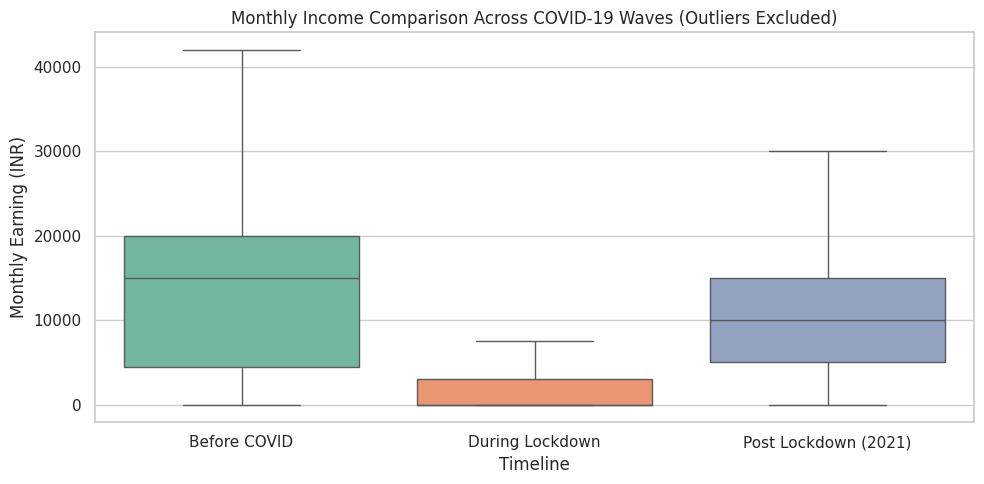

In [ ]:
plt.figure(figsize=(10, 5))
income_cols = ['Earning_Before_COVID', 'Earning_During_Lockdown', 'Earning_Post_COVID']
melted_income = df[income_cols].melt(var_name='Period', value_name='Earning')

sns.boxplot(x='Period', y='Earning', data=melted_income, palette='Set2', showfliers=False)
plt.title('Monthly Income Comparison Across COVID-19 Waves (Outliers Excluded)')
plt.xlabel('Timeline')
plt.ylabel('Monthly Earning (INR)')
plt.xticks([0, 1, 2], ['Before COVID', 'During Lockdown', 'Post Lockdown (2021)'])
plt.tight_layout()
plt.show()

Chart 2: Age Distribution & Family Size

/tmp/ipykernel_840/4081632698.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Family_Size', data=df, ax=axes[1], palette='viridis')


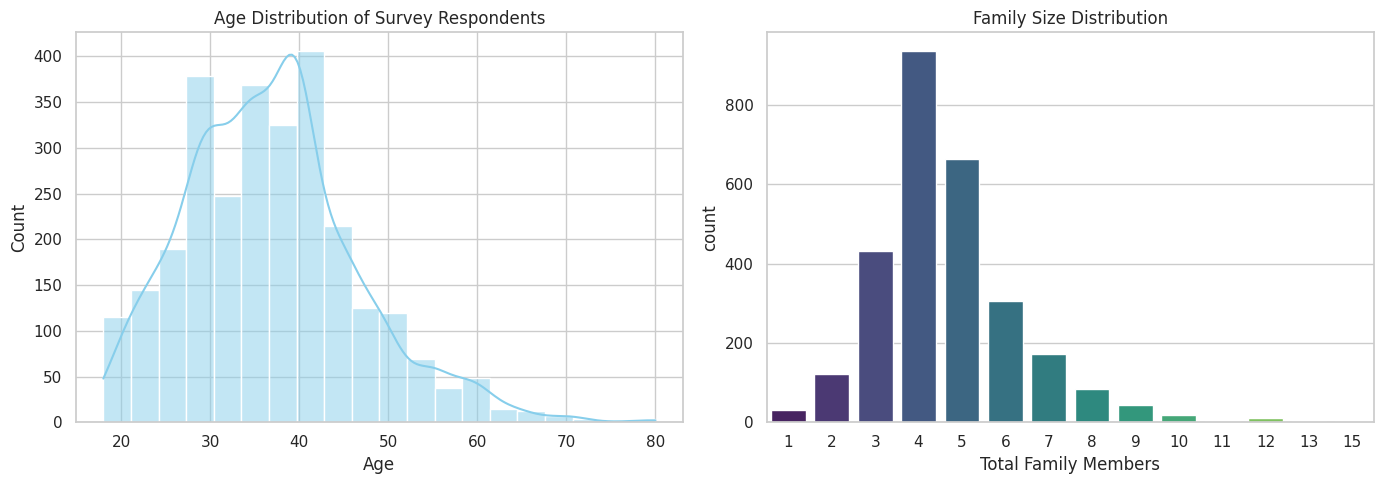

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue', bins=20)
axes[0].set_title('Age Distribution of Survey Respondents')
axes[0].set_xlabel('Age')

sns.countplot(x='Family_Size', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Family Size Distribution')
axes[1].set_xlabel('Total Family Members')

plt.tight_layout()
plt.show()

Chart 3: Financial Stress & Debt Acquisition

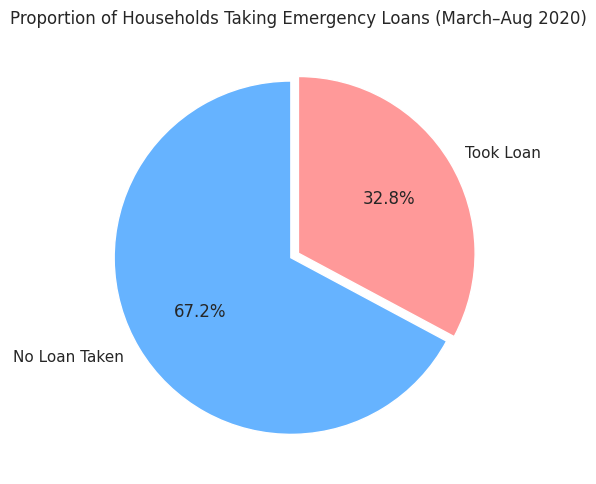

In [ ]:
plt.figure(figsize=(8, 5))
loan_counts = df['Took_Loan'].value_counts()
labels = ['No Loan Taken', 'Took Loan'] if len(loan_counts) == 2 else loan_counts.index

plt.pie(loan_counts, labels=labels, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90, explode=(0.05, 0))
plt.title('Proportion of Households Taking Emergency Loans (March–Aug 2020)')
plt.tight_layout()
plt.show()

Chart 4: Food Insecurity & Job Security Heatmap

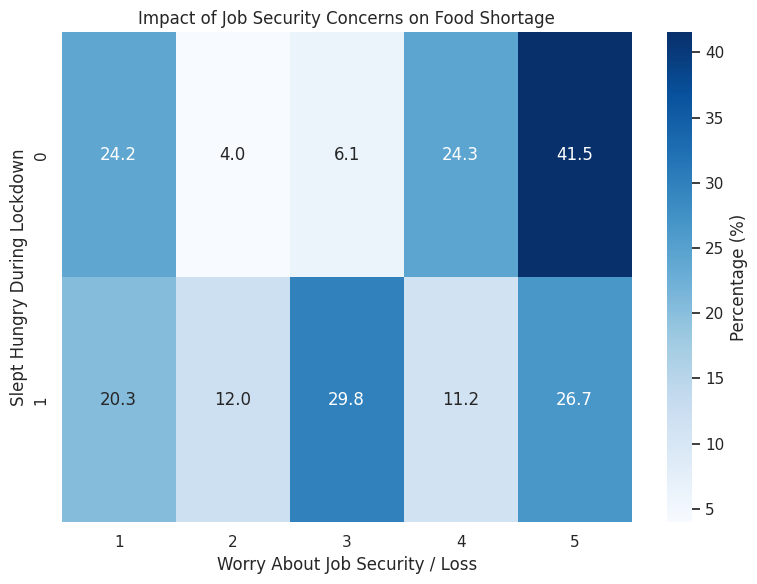

In [ ]:
plt.figure(figsize=(8, 6))
ct = pd.crosstab(df['Slept_Hungry_Lockdown'], df['Job_Security_Worry'], normalize='index') * 100

sns.heatmap(ct, annot=True, fmt=".1f", cmap='Blues', cbar_kws={'label': 'Percentage (%)'})
plt.title('Impact of Job Security Concerns on Food Shortage')
plt.xlabel('Worry About Job Security / Loss')
plt.ylabel('Slept Hungry During Lockdown')
plt.tight_layout()
plt.show()

Chart 5: Dietary Frequency Comparison (Before vs. Post Lockdown)

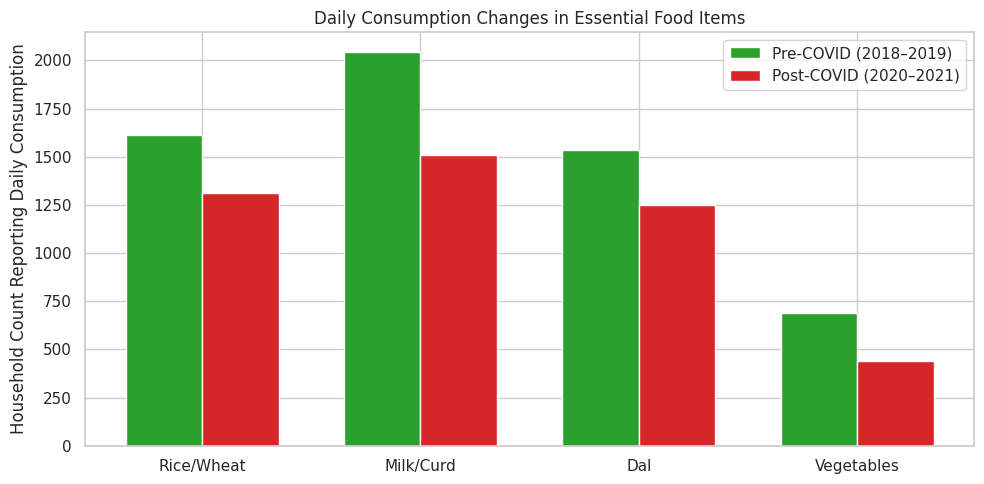

In [ ]:
# Aggregate dietary patterns (Rice/Wheat, Milk/Curd, Dal, Non-Veg, Vegetables)
diet_cols_before = ['Rice/Wheat-Daily- (2018-2019)', 'Milk/Curd-Daily- (2018-2019)', 'Sambar/Dal-Daily- (2018-2019)', 'Vegetables-Daily- (2018-2019)']
diet_cols_after = ['Rice and Wheat-Daily-(2020 to now)', 'Milk/Curd-Daily-(2020 to now)', 'Sambar/Dal-Daily-(2020 to now)', 'Veg-Daily-(2020 to now)']

before_sums = [df[col].sum() for col in diet_cols_before]
after_sums = [df[col].sum() for col in diet_cols_after]

categories = ['Rice/Wheat', 'Milk/Curd', 'Dal', 'Vegetables']
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, before_sums, width, label='Pre-COVID (2018–2019)', color='#2ca02c')
ax.bar(x + width/2, after_sums, width, label='Post-COVID (2020–2021)', color='#d62728')

ax.set_ylabel('Household Count Reporting Daily Consumption')
ax.set_title('Daily Consumption Changes in Essential Food Items')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Ensure renderer displays inside Colab
import plotly.io as pio
pio.renderers.default = "colab"

# Load and rename key variables
df = pd.read_excel('Dataset -COVID-19 and Human Security.xlsx')

df = df.rename(columns={
    'Area/location': 'Location',
    'Age': 'Age',
    'Gender ': 'Gender',
    'Education': 'Education',
    'Total family members                ': 'Family_Size',
    'FAMILY monthly earning now-2021': 'Earning_2021',
    'Monthly earning before COVID?': 'Earning_Before_COVID',
    'Monthly earning during lockdown?': 'Earning_During_Lockdown',
    'Did you take a loan during March-Aug2020?  ': 'Took_Loan',
    'How much taken loan?': 'Loan_Amount',
    'Did your family sleep hungry any time during the lockdown?  ': 'Slept_Hungry_Lockdown',
    'Has COVID make you worry about job security, and fear of loss of job?': 'Job_Security_Worry'
})

Interactive Visual 1: Multi-Stage Earning Distribution (Box Plot)

In [ ]:
# Reshape earnings for comparison
earnings_df = df.melt(
    value_vars=['Earning_Before_COVID', 'Earning_During_Lockdown', 'Earning_2021'],
    var_name='Period',
    value_name='Monthly Earning (INR)'
)

fig1 = px.box(
    earnings_df,
    x='Period',
    y='Monthly Earning (INR)',
    color='Period',
    points="outliers",
    title="<b>Interactive Shift in Household Earnings Across COVID Phases</b>",
    labels={'Period': 'Phase', 'Monthly Earning (INR)': 'Earning (INR)'},
    template="plotly_white"
)
fig1.update_layout(showlegend=False)
fig1.show()

Interactive Visual 2: Emergency Loan Distribution by Education (Sunburst Chart)

In [ ]:
# Clean numeric loan values for display
df['Loan_Amount_Num'] = pd.to_numeric(df['Loan_Amount'], errors='coerce').fillna(0)

fig2 = px.sunburst(
    df,
    path=['Education', 'Took_Loan'],
    values='Loan_Amount_Num',
    color='Took_Loan',
    title="<b>Hierarchical Breakdown: Education Level vs Emergency Loan Status</b>",
    template="plotly_white"
)
fig2.update_traces(textinfo="label+percent parent")
fig2.show()

Interactive Visual 3: Job Security Anxiety vs. Food Shortages (Grouped Bar Chart)

In [ ]:
# Aggregate crosstab data
food_job = df.groupby(['Job_Security_Worry', 'Slept_Hungry_Lockdown']).size().reset_index(name='Count')

fig3 = px.bar(
    food_job,
    x='Job_Security_Worry',
    y='Count',
    color='Slept_Hungry_Lockdown',
    barmode='group',
    title="<b>Impact of Job Security Anxiety on Hunger Exposure</b>",
    labels={
        'Job_Security_Worry': 'Job Loss Worry Level',
        'Slept_Hungry_Lockdown': 'Slept Hungry During Lockdown',
        'Count': 'Number of Respondents'
    },
    template="plotly_white"
)
fig3.show()

Interactive Visual 4: Demographics & Household Loan Size (Scatter Plot)

In [ ]:
fig4 = px.scatter(
    df,
    x='Age',
    y='Loan_Amount_Num',
    size='Family_Size',
    color='Gender',
    hover_data=['Location', 'Education'],
    title="<b>Loan Amount vs Age & Family Size (Bubble Size = Household Members)</b>",
    labels={'Loan_Amount_Num': 'Loan Amount (INR)', 'Age': 'Respondent Age'},
    template="plotly_white"
)
fig4.show()

Interactive Visual 5: Dietary Frequency Breakdown (Interactive Treemap)

In [ ]:
diet_data = pd.DataFrame({
    'Staple': ['Rice/Wheat', 'Milk/Curd', 'Dal/Sambar', 'Vegetables'],
    'Pre_COVID_Daily': [
        df['Rice/Wheat-Daily- (2018-2019)'].sum(),
        df['Milk/Curd-Daily- (2018-2019)'].sum(),
        df['Sambar/Dal-Daily- (2018-2019)'].sum(),
        df['Vegetables-Daily- (2018-2019)'].sum()
    ],
    'Post_COVID_Daily': [
        df['Rice and Wheat-Daily-(2020 to now)'].sum(),
        df['Milk/Curd-Daily-(2020 to now)'].sum(),
        df['Sambar/Dal-Daily-(2020 to now)'].sum(),
        df['Veg-Daily-(2020 to now)'].sum()
    ]
})

fig5 = px.treemap(
    diet_data,
    path=['Staple'],
    values='Post_COVID_Daily',
    color='Pre_COVID_Daily',
    color_continuous_scale='Blues',
    title="<b>Daily Consumption Share Post-COVID (Tile Size = Household Volume)</b>"
)
fig5.show()

Step 5: Exporting Cleaned Data

In [ ]:
# Save the cleaned dataset locally in Colab or download it directly
df.to_csv('Cleaned_COVID_Human_Security.csv', index=False)

# Trigger browser download in Google Colab
files.download('Cleaned_COVID_Human_Security.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Key Analytical Findings Summary
Earnings Shock: A comparison across earnings variables demonstrates a sharp drop in income levels during the lockdown phase compared to pre-COVID levels, with incomplete recovery in early 2021.

Financial Vulnerability: A significant portion of households relied on emergency loans and informal borrowing to cover basic living costs during March–August 2020.

Food Security: Daily consumption rates for essential nutritional items (e.g., vegetables, milk/curd) experienced notable shifts, correlating with households reporting financial distress and job security worries.